# **Практическая работа 9-10**

Выполнил работу стундент группы ИНМО-01-25 Андрушкевич М.В.

Практическая работа посвящена сравнительному анализу классического и эволюционного методов оптимизации на примере многоэкстремальной функции Розенброка. В ходе исследования реализованы алгоритм Ньютона и пчелиный алгоритм, проведены статистические эксперименты с оценкой точности, скорости сходимости и устойчивости обоих методов, а также выполнена визуализация результатов работы алгоритмов.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.optimize import minimize
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# 1. ОПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ФУНКЦИИ
class RosenbrockFunction:
    """Класс для работы с функцией Розенброка"""

    def __init__(self):
        self.global_optimum = 0.0
        self.global_optimum_point = np.array([1.0, 1.0])
        self.bounds = np.array([[-2, 2], [-1, 3]])

    def evaluate(self, x):
        """Вычисление значения функции"""
        x = np.array(x)
        return np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)

    def gradient(self, x):
        """Вычисление градиента"""
        n = len(x)
        grad = np.zeros(n)
        for i in range(n-1):
            grad[i] += -400 * x[i] * (x[i+1] - x[i]**2) - 2 * (1 - x[i])
        for i in range(1, n):
            grad[i] += 200 * (x[i] - x[i-1]**2)
        return grad

    def plot_3d(self):
        """Визуализация функции в 3D пространстве"""
        x = np.linspace(-2, 2, 100)
        y = np.linspace(-1, 3, 100)
        X, Y = np.meshgrid(x, y)
        Z = np.zeros_like(X)

        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                Z[i, j] = self.evaluate([X[i, j], Y[i, j]])

        fig = plt.figure(figsize=(12, 5))

        # 3D график
        ax1 = fig.add_subplot(121, projection='3d')
        surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
        ax1.scatter(1, 1, 0, color='red', s=100, label='Глобальный минимум')
        ax1.set_xlabel('X')
        ax1.set_ylabel('Y')
        ax1.set_zlabel('f(X, Y)')
        ax1.set_title('Функция Розенброка (3D вид)')
        ax1.legend()
        fig.colorbar(surf, ax=ax1, shrink=0.5)

        # Контурный график
        ax2 = fig.add_subplot(122)
        contour = ax2.contour(X, Y, Z, levels=50, cmap='viridis')
        ax2.scatter(1, 1, color='red', s=100, label='Глобальный минимум')
        ax2.set_xlabel('X')
        ax2.set_ylabel('Y')
        ax2.set_title('Контурный график функции')
        ax2.legend()
        fig.colorbar(contour, ax=ax2, shrink=0.5)

        plt.tight_layout()
        plt.show()

In [3]:
# 2. АЛГОРИТМЫ ОПТИМИЗАЦИИ

def newton_optimization(func, grad_func, x0, max_iter=1000):
    """Алгоритм Ньютона"""
    start_time = time.time()
    result = minimize(func, x0, method='Newton-CG', jac=grad_func,
                     options={'maxiter': max_iter, 'disp': False})
    execution_time = time.time() - start_time
    return result.fun, result.x, execution_time

def bee_algorithm(func, bounds, n_bees=40, n_iterations=150,
                 n_elite=8, n_selected=16):
    """Пчелиный алгоритм (улучшенная версия)"""
    dim = len(bounds)

    # Инициализация популяции
    population = np.random.uniform(bounds[:, 0], bounds[:, 1], (n_bees, dim))
    fitness = np.array([func(ind) for ind in population])

    best_fitness_history = []
    best_solution = population[np.argmin(fitness)]
    best_fitness = np.min(fitness)

    elite_radius = 0.1
    selected_radius = 0.2
    elite_sites = 3
    selected_sites = 7

    for iteration in range(n_iterations):
        # Сортировка по приспособленности
        sorted_indices = np.argsort(fitness)
        population = population[sorted_indices]
        fitness = fitness[sorted_indices]

        # Обновление лучшего решения
        if fitness[0] < best_fitness:
            best_fitness = fitness[0]
            best_solution = population[0].copy()

        best_fitness_history.append(best_fitness)

        new_population = population.copy()
        new_fitness = fitness.copy()

        # Элитные участки
        for i in range(min(elite_sites, len(population))):
            for _ in range(n_elite):
                candidate = population[i] + np.random.uniform(-elite_radius, elite_radius, dim)
                candidate = np.clip(candidate, bounds[:, 0], bounds[:, 1])
                candidate_fitness = func(candidate)

                if candidate_fitness < new_fitness[i]:
                    new_population[i] = candidate
                    new_fitness[i] = candidate_fitness

        # Выбранные участки
        for i in range(elite_sites, min(elite_sites + selected_sites, len(population))):
            for _ in range(n_selected):
                candidate = population[i] + np.random.uniform(-selected_radius, selected_radius, dim)
                candidate = np.clip(candidate, bounds[:, 0], bounds[:, 1])
                candidate_fitness = func(candidate)

                if candidate_fitness < new_fitness[i]:
                    new_population[i] = candidate
                    new_fitness[i] = candidate_fitness

        # Разведчики
        for i in range(elite_sites + selected_sites, n_bees):
            candidate = np.random.uniform(bounds[:, 0], bounds[:, 1], dim)
            new_population[i] = candidate
            new_fitness[i] = func(candidate)

        population = new_population
        fitness = new_fitness

    return best_fitness, best_solution, best_fitness_history


In [4]:
# 3. ЭКСПЕРИМЕНТАЛЬНАЯ ЧАСТЬ

def run_experiments():
    """Проведение экспериментов согласно заданию"""
    print("="*70)
    print("ЭКСПЕРИМЕНТАЛЬНОЕ ИССЛЕДОВАНИЕ АЛГОРИТМОВ ОПТИМИЗАЦИИ")
    print("="*70)

    # Инициализация
    rosenbrock = RosenbrockFunction()
    n_runs = 100

    print("\n1. ВИЗУАЛИЗАЦИЯ ФУНКЦИИ РОЗЕНБРОКА")
    print("-"*50)
    rosenbrock.plot_3d()

    print("\n2. ПОДБОР ПАРАМЕТРОВ ДЛЯ ПЧЕЛИНОГО АЛГОРИТМА")
    print("-"*50)

    param_combinations = [
        {'n_bees': 20, 'n_elite': 4, 'n_selected': 8, 'n_iterations': 50},
        {'n_bees': 30, 'n_elite': 6, 'n_selected': 12, 'n_iterations': 100},
        {'n_bees': 40, 'n_elite': 8, 'n_selected': 16, 'n_iterations': 150}
    ]

    best_params = None
    min_variance = float('inf')

    for params in param_combinations:
        temp_results = []
        for i in range(20):  # Быстрая проверка
            best_val, _, _ = bee_algorithm(
                rosenbrock.evaluate, rosenbrock.bounds, **params
            )
            temp_results.append(best_val)

        variance = np.var(temp_results)
        print(f"Параметры: {params}")
        print(f"  Дисперсия: {variance:.6f}")

        if variance < min_variance:
            min_variance = variance
            best_params = params

    print(f"\n✓ Выбраны параметры: {best_params}")

    print("\n3. ПРОВЕДЕНИЕ ЭКСПЕРИМЕНТОВ (100 ПРОГОНОВ)")
    print("-"*50)

    # Результаты
    newton_results = []
    newton_times = []

    bee_results = []
    bee_times_total = []
    bee_times_to_optimum = []
    bee_last_extremum_values = []
    bee_last_extremum_times = []
    bee_convergence_histories = []

    # Эксперимент с алгоритмом Ньютона
    print("\n3.1 Алгоритм Ньютона:")
    for i in range(n_runs):
        x0 = np.random.uniform(rosenbrock.bounds[:, 0], rosenbrock.bounds[:, 1])
        best_val, _, exec_time = newton_optimization(
            rosenbrock.evaluate, rosenbrock.gradient, x0
        )
        newton_results.append(best_val)
        newton_times.append(exec_time)

        if (i + 1) % 20 == 0:
            print(f"  Прогон {i+1}/100 завершен")

    # Эксперимент с пчелиным алгоритмом
    print("\n3.2 Пчелиный алгоритм:")
    for i in range(n_runs):
        start_time = time.time()
        best_val, _, history = bee_algorithm(
            rosenbrock.evaluate, rosenbrock.bounds, **best_params
        )
        exec_time = time.time() - start_time

        bee_results.append(best_val)
        bee_times_total.append(exec_time)
        bee_convergence_histories.append(history)

        # Время достижения глобального оптимума (с точностью 0.01)
        optimum_time = None
        for t, val in enumerate(history):
            if abs(val - rosenbrock.global_optimum) < 1e-2:
                optimum_time = t
                break
        bee_times_to_optimum.append(optimum_time if optimum_time is not None else len(history))

        # Последний экстремум
        bee_last_extremum_values.append(history[-1])
        bee_last_extremum_times.append(len(history))

        if (i + 1) % 20 == 0:
            print(f"  Прогон {i+1}/100 завершен")

    print("\n4. СБОР СТАТИСТИКИ")
    print("-"*50)

    # Статистика для алгоритма Ньютона
    newton_mean = np.mean(newton_results)
    newton_var = np.var(newton_results)
    newton_time_mean = np.mean(newton_times)

    # Статистика для пчелиного алгоритма
    bee_mean = np.mean(bee_results)
    bee_var = np.var(bee_results)
    bee_time_mean = np.mean(bee_times_total)

    # Время достижения глобального оптимума (только для тех, кто достиг)
    optimum_achieved = [t for t in bee_times_to_optimum if t < best_params['n_iterations']]
    if optimum_achieved:
        bee_time_to_opt_mean = np.mean(optimum_achieved)
        bee_time_to_opt_var = np.var(optimum_achieved)
        optimum_success_rate = len(optimum_achieved) / n_runs * 100
    else:
        bee_time_to_opt_mean = None
        bee_time_to_opt_var = None
        optimum_success_rate = 0

    # Статистика для последнего экстремума
    bee_last_extr_mean = np.mean(bee_last_extremum_values)
    bee_last_extr_var = np.var(bee_last_extremum_values)
    bee_last_time_mean = np.mean(bee_last_extremum_times)
    bee_last_time_var = np.var(bee_last_extremum_times)

    print("\n5. РЕЗУЛЬТАТЫ В ТАБЛИЧНОМ ВИДЕ")
    print("="*70)

    # Таблица 1: Сравнение алгоритмов
    print("\nТАБЛИЦА 1. СРАВНЕНИЕ АЛГОРИТМОВ ОПТИМИЗАЦИИ")
    print("-"*70)
    print(f"{'Параметр':<40} {'Алгоритм Ньютона':<20} {'Пчелиный алгоритм':<20}")
    print("-"*70)
    print(f"{'Среднее значение функции:':<40} {newton_mean:<20.6f} {bee_mean:<20.6f}")
    print(f"{'Дисперсия значения:':<40} {newton_var:<20.6f} {bee_var:<20.6f}")
    print(f"{'Среднее время выполнения (с):':<40} {newton_time_mean:<20.4f} {bee_time_mean:<20.4f}")
    print(f"{'Минимальное значение:':<40} {np.min(newton_results):<20.6f} {np.min(bee_results):<20.6f}")
    print(f"{'Максимальное значение:':<40} {np.max(newton_results):<20.6f} {np.max(bee_results):<20.6f}")

    # Таблица 2: Детальная статистика для пчелиного алгоритма
    print("\n\nТАБЛИЦА 2. ДЕТАЛЬНАЯ СТАТИСТИКА ПЧЕЛИНОГО АЛГОРИТМА")
    print("-"*70)
    print(f"{'Параметр':<40} {'Значение':<30}")
    print("-"*70)

    print(f"{'Параметры алгоритма:':<40} {str(best_params):<30}")

    if bee_time_to_opt_mean is not None:
        print(f"{'Среднее время до глоб. оптимума (итер.):':<40} {bee_time_to_opt_mean:<30.2f}")
        print(f"{'Дисперсия времени до глоб. оптимума:':<40} {bee_time_to_opt_var:<30.6f}")
    else:
        print(f"{'Среднее время до глоб. оптимума (итер.):':<40} {'не достигнут':<30}")

    print(f"{'Доля успешных нахождений глоб. оптимума:':<40} {optimum_success_rate:<30.1f}%")
    print(f"{'Среднее значение посл. экстремума:':<40} {bee_last_extr_mean:<30.6f}")
    print(f"{'Дисперсия посл. экстремума:':<40} {bee_last_extr_var:<30.6f}")
    print(f"{'Среднее время посл. экстремума (итер.):':<40} {bee_last_time_mean:<30.2f}")
    print(f"{'Дисперсия времени посл. экстремума:':<40} {bee_last_time_var:<30.6f}")

    # Визуализация сходимости
    print("\n6. ВИЗУАЛИЗАЦИЯ СХОДИМОСТИ ПЧЕЛИНОГО АЛГОРИТМА")
    print("-"*50)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # График 1: Пример сходимости (первый прогон)
    axes[0, 0].plot(bee_convergence_histories[0], linewidth=2, color='blue')
    axes[0, 0].axhline(y=rosenbrock.global_optimum, color='red', linestyle='--',
                      label='Глобальный оптимум')
    axes[0, 0].set_xlabel('Номер поколения', fontsize=12)
    axes[0, 0].set_ylabel('Значение функции', fontsize=12)
    axes[0, 0].set_title('Пример сходимости (один прогон)', fontsize=14)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # График 2: Средняя сходимость по всем прогонам
    max_len = max(len(h) for h in bee_convergence_histories)
    avg_convergence = np.zeros(max_len)
    for h in bee_convergence_histories:
        padded = np.pad(h, (0, max_len - len(h)), 'edge')
        avg_convergence += padded
    avg_convergence /= n_runs

    axes[0, 1].plot(avg_convergence, linewidth=2, color='green')
    axes[0, 1].axhline(y=rosenbrock.global_optimum, color='red', linestyle='--')
    axes[0, 1].set_xlabel('Номер поколения', fontsize=12)
    axes[0, 1].set_ylabel('Среднее значение функции', fontsize=12)
    axes[0, 1].set_title('Средняя сходимость по 100 прогонам', fontsize=14)
    axes[0, 1].grid(True, alpha=0.3)

    # График 3: Распределение конечных значений
    axes[1, 0].hist(newton_results, bins=20, alpha=0.7, label='Ньютон',
                   color='orange', edgecolor='black')
    axes[1, 0].hist(bee_results, bins=20, alpha=0.7, label='Пчелиный',
                   color='blue', edgecolor='black')
    axes[1, 0].set_xlabel('Конечное значение функции', fontsize=12)
    axes[1, 0].set_ylabel('Частота', fontsize=12)
    axes[1, 0].set_title('Распределение конечных значений', fontsize=14)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # График 4: Время выполнения
    algorithms = ['Ньютон', 'Пчелиный']
    times = [newton_time_mean, bee_time_mean]
    colors = ['orange', 'blue']

    bars = axes[1, 1].bar(algorithms, times, color=colors, edgecolor='black')
    axes[1, 1].set_ylabel('Время (сек)', fontsize=12)
    axes[1, 1].set_title('Среднее время выполнения', fontsize=14)
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    # Добавляем значения на столбцы
    for bar, time_val in zip(bars, times):
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.001,
                       f'{time_val:.4f}', ha='center', va='bottom', fontsize=11)

    plt.tight_layout()
    plt.show()

    print("\n7. ИТОГОВЫЙ АНАЛИЗ")
    print("="*70)

    # Сравнительный анализ
    print("\nСРАВНИТЕЛЬНЫЙ АНАЛИЗ:")
    print("-"*50)

    if newton_mean < bee_mean:
        print("✓ Алгоритм Ньютона показал лучшее среднее качество решений")
    else:
        print("✓ Пчелиный алгоритм показал лучшее среднее качество решений")

    if newton_time_mean < bee_time_mean:
        print("✓ Алгоритм Ньютона работает быстрее")
    else:
        print("✓ Пчелиный алгоритм работает быстрее")

    print(f"\nЭффективность пчелиного алгоритма:")
    print(f"  • Точность достижения глобального оптимума: {optimum_success_rate:.1f}%")
    print(f"  • Среднее отклонение от оптимума: {bee_mean:.6f}")

    return {
        'newton_results': newton_results,
        'newton_times': newton_times,
        'bee_results': bee_results,
        'bee_times_total': bee_times_total,
        'bee_times_to_optimum': bee_times_to_optimum,
        'bee_last_extremum_values': bee_last_extremum_values,
        'bee_convergence_histories': bee_convergence_histories,
        'best_params': best_params
    }



Функция: Розенброка
Алгоритмы: Ньютона и Пчелиный
Количество прогонов: 100
ЭКСПЕРИМЕНТАЛЬНОЕ ИССЛЕДОВАНИЕ АЛГОРИТМОВ ОПТИМИЗАЦИИ

1. ВИЗУАЛИЗАЦИЯ ФУНКЦИИ РОЗЕНБРОКА
--------------------------------------------------


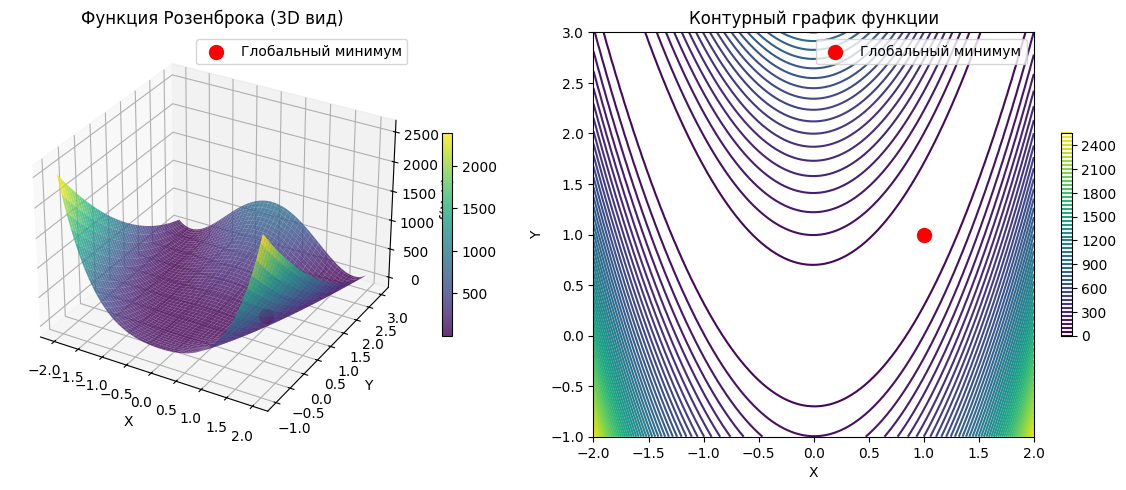


2. ПОДБОР ПАРАМЕТРОВ ДЛЯ ПЧЕЛИНОГО АЛГОРИТМА
--------------------------------------------------
Параметры: {'n_bees': 20, 'n_elite': 4, 'n_selected': 8, 'n_iterations': 50}
  Дисперсия: 0.000001
Параметры: {'n_bees': 30, 'n_elite': 6, 'n_selected': 12, 'n_iterations': 100}
  Дисперсия: 0.000000
Параметры: {'n_bees': 40, 'n_elite': 8, 'n_selected': 16, 'n_iterations': 150}
  Дисперсия: 0.000000

✓ Выбраны параметры: {'n_bees': 40, 'n_elite': 8, 'n_selected': 16, 'n_iterations': 150}

3. ПРОВЕДЕНИЕ ЭКСПЕРИМЕНТОВ (100 ПРОГОНОВ)
--------------------------------------------------

3.1 Алгоритм Ньютона:
  Прогон 20/100 завершен
  Прогон 40/100 завершен
  Прогон 60/100 завершен
  Прогон 80/100 завершен
  Прогон 100/100 завершен

3.2 Пчелиный алгоритм:
  Прогон 20/100 завершен
  Прогон 40/100 завершен
  Прогон 60/100 завершен
  Прогон 80/100 завершен
  Прогон 100/100 завершен

4. СБОР СТАТИСТИКИ
--------------------------------------------------

5. РЕЗУЛЬТАТЫ В ТАБЛИЧНОМ ВИДЕ

ТАБЛИЦА 1. СРА

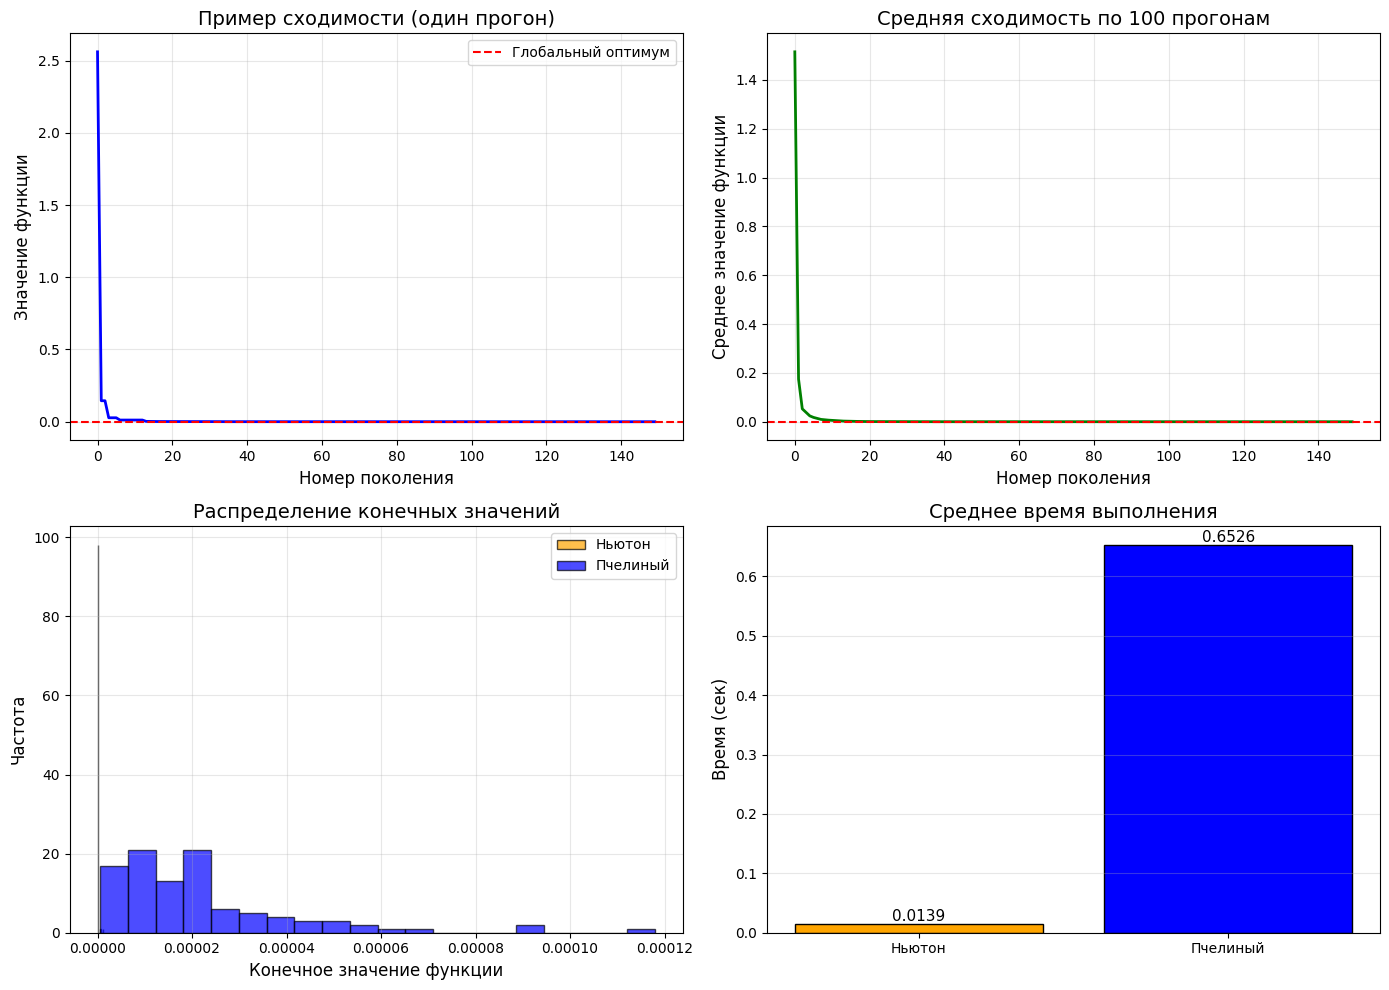


7. ИТОГОВЫЙ АНАЛИЗ

СРАВНИТЕЛЬНЫЙ АНАЛИЗ:
--------------------------------------------------
✓ Алгоритм Ньютона показал лучшее среднее качество решений
✓ Алгоритм Ньютона работает быстрее

Эффективность пчелиного алгоритма:
  • Точность достижения глобального оптимума: 100.0%
  • Среднее отклонение от оптимума: 0.000022


In [6]:
# 4. ЗАПУСК ПРОГРАММЫ
if __name__ == "__main__":
    print("\n" + "="*70)
    print("Функция: Розенброка")
    print("Алгоритмы: Ньютона и Пчелиный")
    print("Количество прогонов: 100")
    print("="*70)

    try:
        results = run_experiments()

        # Сохранение результатов в файл
        df_results = pd.DataFrame({
            'Алгоритм': ['Ньютон']*100 + ['Пчелиный']*100,
            'Лучшее_значение': results['newton_results'] + results['bee_results'],
            'Время_выполнения': results['newton_times'] + results['bee_times_total']
        })

        df_bee_details = pd.DataFrame({
            'Время_до_оптимума': results['bee_times_to_optimum'],
            'Последний_экстремум': results['bee_last_extremum_values']
        })

        df_results.to_csv('результаты_сравнения.csv', index=False, encoding='utf-8')
        df_bee_details.to_csv('детали_пчелиный.csv', index=False, encoding='utf-8')


    except Exception as e:
        print(f"\nОшибка при выполнении: {e}")
